<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/17_regularized-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 17: Regularized regression

This homework assignment is designed to give you an intuition as an interesting property of regularization in the context of ultra-high dimensional statistical problems.

You won't need to load in any data for this homework.

---
## 1. Simulating & visualizing data (2 points)

We are going to be looking at what happens in the context where $p>n$. In order to have total control over our data, we will use simulations for this homework. First, we will need to load the `glmnet`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [2]:
# WRITE YOUR CODE HERE
install.packages("glmnet")
library(glmnet)
library(tidyverse)
library(ggplot2)


also installing the dependency ‘shape’





The downloaded binary packages are in
	/var/folders/xn/6zv05bqd6pg_55q7h9xf15h00000gn/T//RtmpOc3T7h/downloaded_packages


Loading required package: Matrix

Loaded glmnet 4.1-10

Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


We are going to generate a data set with complex structure and try to recover it using polynomial models. For simplicity sake, use the following code to produce a response variable, $y$ that has complex structure.

*Hint: Look up what a cosine function looks like if you need a reminder.*

In [3]:
# Generate data
set.seed(121)
sigma_noise = .5
x=seq(-9,9,by=.18)
n=length(x)
y = 0.1*x + cos(x) + cos(x/20)+rnorm(n,sd=sigma_noise)

(a) Break the data into a training set (n=50) and test set (n=51) using the `sample` function to randomly select subsets of x and y.  Make a separate data frame for the training and test data.

(**Note**: *Do not* just take the first 50 observations to be the training set and last 51 observations to be the test set.)

In [4]:
# WRITE YOUR CODE HERE
set.seed(121) 

n = length(x)

train = sample(1:n, size=50)
test = setdiff(1:n, train)

df_train = data.frame(x =x[train], y=y[train])
df_test  = data.frame(x=x[test],  y=y[test])

nrow(df_train) 
nrow(df_test) 


[1] 50

[1] 51

(b) Plot the training data ($x$ \& $y$). Describe the relationship that you see in the training data.

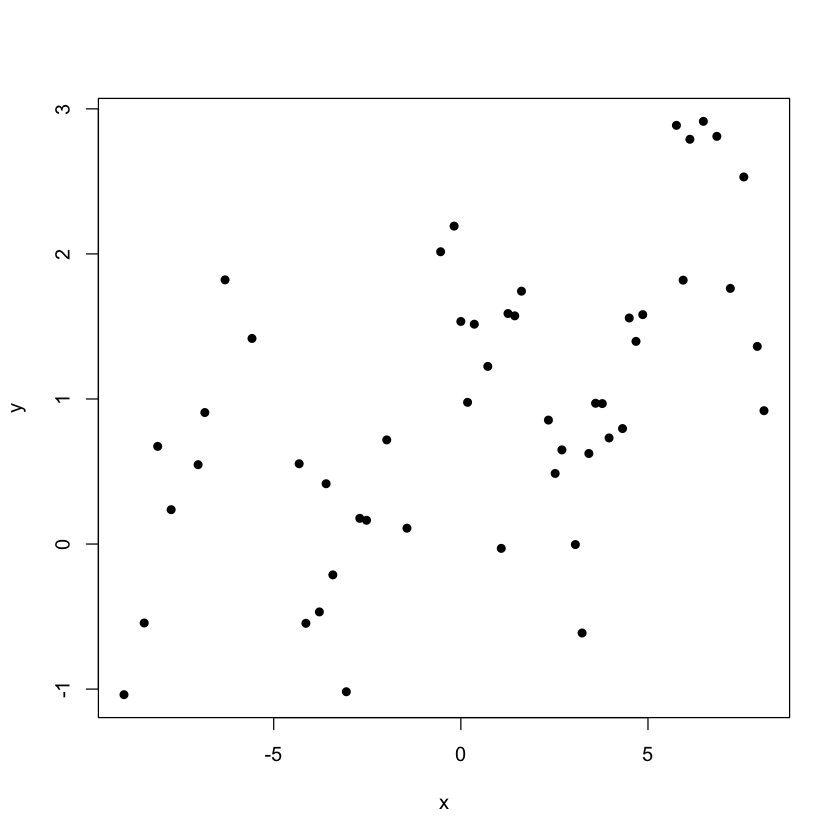

In [8]:
# WRITE YOUR CODE HERE

plot(df_train$x, df_train$y, xlab = "x", ylab = "y", pch = 16)


How would you describe the relationship between $x$ and $y$ based on this plot?

> *Write your response here*
> There appears to be a generally positive but non-linear relationship between x and y. This relationship also appears to have a bit of noise/error.

---
## 2. Bias-variance tradeoff: polynomial regression (4 points)

Recall that in polynomial regression we increase model complexity by expanding $x$ out to the power $k$ (which we call degree).

$$
Y = \hat{\beta}_0 + \sum_{j=1}^K \hat{\beta}_j X^j
\;=\; \operatorname{poly}(X, K)
$$

(a) Fit a 2nd degree polynomial regression model to the training data. Plot the results.


*Hint: Use the* `help` *function to see how to use the* `stat_smooth()` *and* `poly()` *functions.*


Call:
lm(formula = y ~ poly(x, 2), data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.83059 -0.61617  0.02948  0.64707  1.58144 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.9608     0.1176   8.170 1.42e-10 ***
poly(x, 2)1   3.9599     0.8315   4.762 1.87e-05 ***
poly(x, 2)2   0.8779     0.8315   1.056    0.296    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8315 on 47 degrees of freedom
Multiple R-squared:  0.3361,	Adjusted R-squared:  0.3078 
F-statistic:  11.9 on 2 and 47 DF,  p-value: 6.601e-05


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


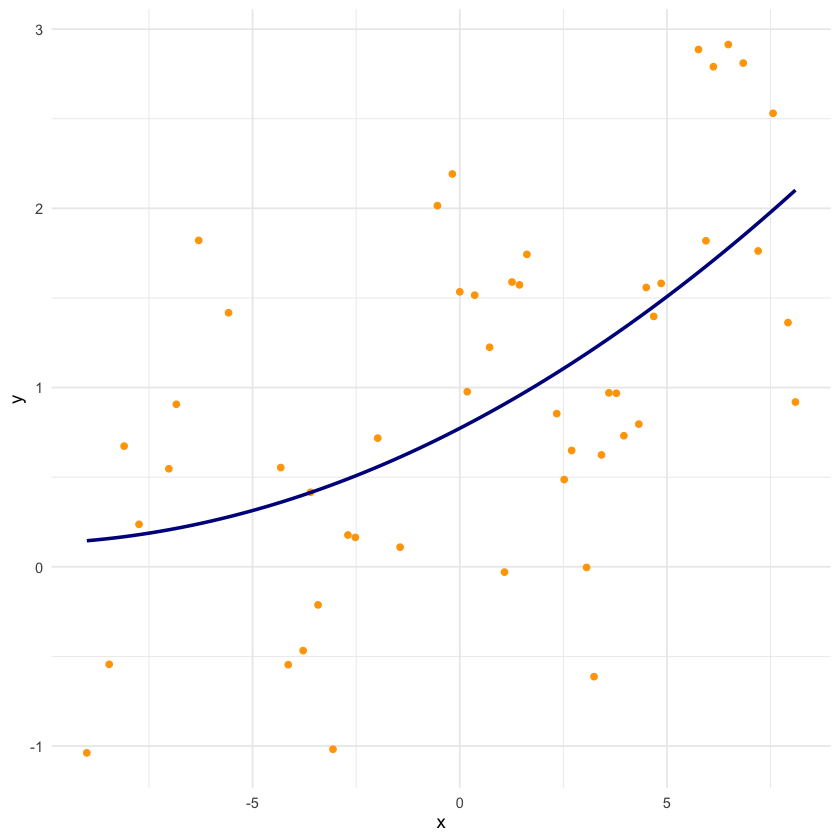

poly {stats},R Documentation
"x, newdata","a numeric vector or an object with mode ""numeric"" (such as a Date) at which to evaluate the polynomial. x can also be a matrix. Missing values are not allowed in x."
degree,"the degree of the polynomial. Must be less than the number of unique points when raw is false, as by default."
coefs,"for prediction, coefficients from a previous fit."
raw,"if true, use raw and not orthogonal polynomials."
simple,logical indicating if a simple matrix (with no further attributes but dimnames) should be returned. For speedup only.
object,"an object inheriting from class ""poly"", normally the result of a call to poly with a single vector argument."
...,"poly, polym: further vectors. predict.poly: arguments to be passed to or from other methods."


In [11]:
# WRITE YOUR CODE HERE
help(poly)

model_poly <- lm(y ~poly(x, 2), data=df_train)
summary(model_poly)

ggplot(df_train, aes(x=x, y=y)) +
  geom_point(color = "orange") +
  stat_smooth(method ="lm", formula =y ~ poly(x, 2), se= FALSE, color= "darkblue", size=1) +
  labs(x ="x", y ="y") +
  theme_minimal()


How well does this 2nd degree polynomial model qualitatively fit the data? Could it do better?

> *Write your response here*
> Quadratic model does not appear to fit the data very well aside from capturing the generally positive trend. We simulated this data with a cosinor term, which means a quadratic model will be too simple and have a lot of bias. The large residual standard error suggests the same thing. 

(b) Fit a 12th degree polynomial to the data. Does this do qualitatively better or worse than the 2nd degree model?


Call:
lm(formula = y ~ poly(x, 12), data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.34178 -0.27127  0.06749  0.34723  0.75104 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)     0.9608     0.0756  12.709 4.57e-15 ***
poly(x, 12)1    3.9599     0.5345   7.408 8.17e-09 ***
poly(x, 12)2    0.8779     0.5345   1.642  0.10899    
poly(x, 12)3    0.4594     0.5345   0.859  0.39566    
poly(x, 12)4   -1.1742     0.5345  -2.197  0.03440 *  
poly(x, 12)5    0.1795     0.5345   0.336  0.73891    
poly(x, 12)6   -3.6957     0.5345  -6.914 3.70e-08 ***
poly(x, 12)7   -1.3201     0.5345  -2.470  0.01827 *  
poly(x, 12)8    1.9039     0.5345   3.562  0.00103 ** 
poly(x, 12)9    0.5383     0.5345   1.007  0.32044    
poly(x, 12)10  -0.9468     0.5345  -1.771  0.08475 .  
poly(x, 12)11   0.1844     0.5345   0.345  0.73207    
poly(x, 12)12  -0.2417     0.5345  -0.452  0.65380    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 

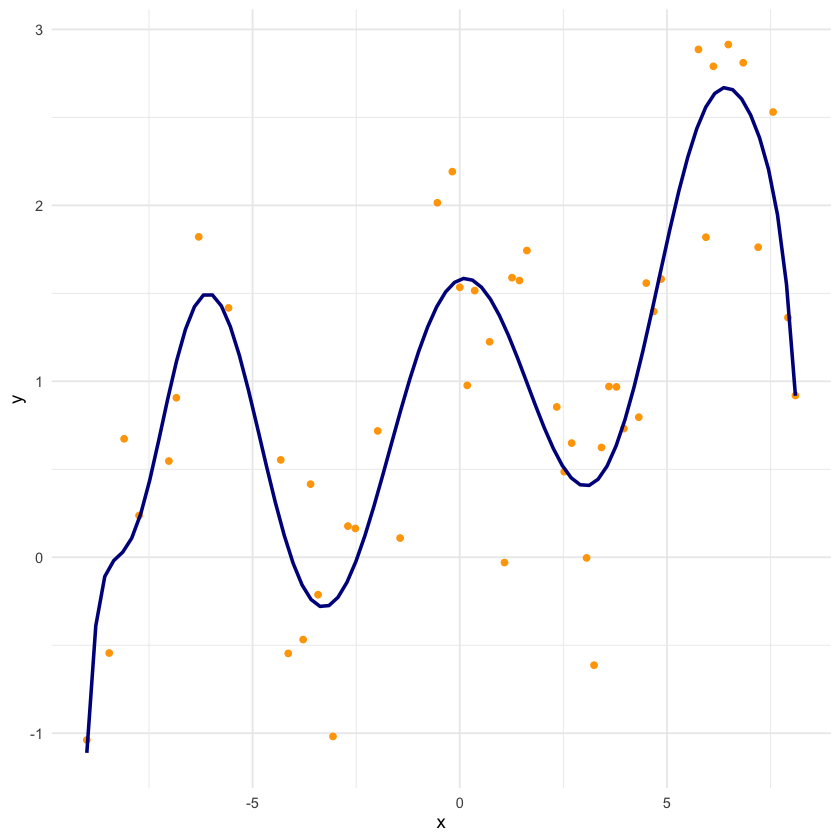

In [12]:
# WRITE YOUR CODE HERE
model_poly_12 <- lm(y ~ poly(x, 12), data=df_train)
summary(model_poly_12)

ggplot(df_train, aes(x=x, y=y)) +
  geom_point(color = "orange") +
  stat_smooth(method ="lm", formula =y ~ poly(x, 12), se= FALSE, color= "darkblue", size=1) +
  labs(x ="x", y ="y") +
  theme_minimal()


> *Write your response here*
> This appears qualitatively to fit the data better, capturing the oscillatory pattern. The residual standard error also went down. 

(c) Modify the loop below to estimate the bias-variance tradeoff as model complexity (i.e., degree of the polynomial model, $k$) increases from 2 to 50. Use the training data to fit the model and test data to evaluate its predictive accuracy.

Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.


(**Note**: We are using median accuracies here because there are often 1 or 2 outlier values in the higher degree polynomial models that can throw off the accuracy estimates).

In [23]:
# Now do the variance-bias trade off analysis using regular regression
degree = seq(2,50)

# Need to setup your output vectors
train_error = matrix(data=NA,nrow=length(degree),ncol=1)
test_error = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    # WRITE YOUR CODE HERE
    model = lm(y ~ poly(x, k), data = df_train)

    train_y = predict(model, newdata = df_train)
    test_y  = predict(model, newdata = df_test)

    train_error[k-1] = median((df_train$y - train_y)^2)
    test_error[k-1]  = median((df_test$y - test_y)^2)
}

# Plot your results here
# WRITE YOUR CODE HERE
plot(degree, train_error, type= "l", col = "darkblue", lwd = 2, ylim = range(c(train_error, test_error)))

lines(degree, test_error, col="orange", lwd= 2)

legend("topright", legend = c("Train Error", "Test Error"), col = c("darkblue", "orange"), lwd = 2)



ERROR: Error in poly(x, k): 'degree' must be less than number of unique points


What do you see as $k$ increase?

> *Write your response here*
>Model did not converge because you can't have a model where the number of parameters are greater than the number of observations (p > n). There is not enough information to be able to estimate all of the parameters. 

(d) Now copy the code above and let's see what happens when we go beyond $p=n$ (remember, in this case $k=p$). Test polynomial models up to $k=150$. Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.

Use the `geom_vline()` function in `ggplot` to draw a vertical line where $k=n$ (here $n$ is the number of observations in the training set). This will make it clear where we cross the threshold for finding *unique* solutions in our data.



In [ ]:
# WRITE YOUR CODE HERE
# Not applicable since above did not converge. 


What do you see as $k$ gets larger than $n$?

> *Write your response here*
>Not applicable. 

---
## 3. Applying regularization to the model fits (2 points)

Repeat the previous bias-variance tradeoff test, going up to $k=150$, but now use ridge regression with a sparsity parameter of $\lambda=0.00005$. Plot your results the same way as last time.

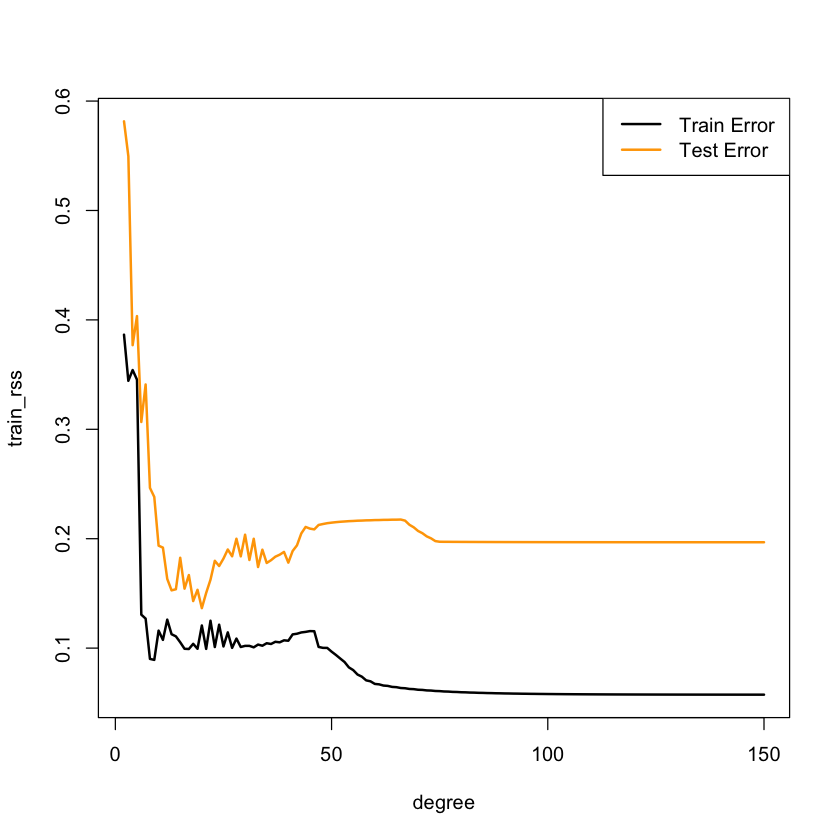

In [33]:
# Now do the variance-bias trade off analysis using ridge regression
lambda=0.00005
degree = seq(2,150)

rm(train_rss, test_rss)
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
# WRITE YOUR CODE HERE  
train_x = as.matrix(poly(df_train$x, degree = k, raw = TRUE))
test_x = as.matrix(poly(df_test$x, degree = k, raw = TRUE))

fit = glmnet(train_x, df_train$y, alpha = 0, lambda = lambda, standardize = TRUE)

train_y = as.vector(predict(fit, newx = train_x, s = lambda[1]))
test_y = as.vector(predict(fit, newx = test_x, s = lambda[1]))

train_rss[k - 1] = median((df_train$y - train_y)^2)
test_rss[k - 1] = median((df_test$y - test_y)^2)
}

# Plot your results here
# WRITE YOUR CODE HERE
plot(degree, train_rss, type = "l", lwd = 2, ylim = range(c(train_rss, test_rss)))

lines(degree, test_rss, col = "orange", lwd = 2)

legend("topright",
       legend = c("Train Error", "Test Error"),
       col = c("black", "orange"),
       lwd = 2)


What happens now when $k$ gets larger than $n$?

> *Write your response here*
>As K increases, the training error gets smaller and eventually levels off when it gets larger than. This happens because ridge regression penalizes coefficients to prevent overfitting as model complexity increases.

---
## 4. Reflection (2 points)

The simulations above should have shown that, when applying a regularization (i.e., a sparsity constraint), the behavior of the bias-variance tradeoff changes. Explain why this happens.

> *Write your response here*
> Bias-variance behavior changes because regularization adds a penalty that shrinks coefficient estimates towards (or to) 0, which reduces model flexibility. This slighly increases bias but lowers the variance, making the model more stable and improving generalization at higher degrees of model complexity.

---
## Bonus (1 extra credit point)
Recall that the $p=n$ threshold defines the limit for finding a *unique* solution to $Y=F(X)$ (i.e., there is only one combination of regression coefficients that is *best* at explaining variance in $Y$). With this in mind, what is regularization doing that works around this upper limit?

> *Write your response here*
Instead of minimizing only the sum of squared residuals, it adds a penalty on the size of the coefficients. This makes it so that among the many possible solutions, those with large or unstable coefficients are penalized, leading to a single, well-defined and stable solution even when p is larger than n. 

**DUE:** 5pm EST, April 7, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*